# AI ASSIGNMENT
# TEAM MEMBERS- JENIL PAGHDAR (24BTM051) & JENIN PATEL (24BTM050)
# SUBMITTING TO: DR. REBAKAH GEDDAM
# DATASET: HOUSE PRICE PRDICTION (https://www.kaggle.com/datasets/vasantharank/synthetic-house-price-prediction-dataset)

## ABOUT DATASET


		THE DATASET IS REGARDING THE HOUSE PRICE


     Bedrooms  Bathrooms  Square Feet  House Age  Location Rating  Price
0           3          1         2493       96.0                1   4973
1           1          1          933       89.0                4   1845
2           3          1         3938       38.0                3   7880
3           3          1         3878       84.0                2   7747
4           1          2         1747       48.0                4   3487
..        ...        ...          ...        ...              ...    ...
995         2          1         2013        NaN                1   4034
996         2          2         1959       80.0                3   3906
997         3          1         1354       10.0                2   2721
998         3          1         1203       95.0                4   2393
999         1          1         1691        NaN                2   3385

[1000 rows x 6 columns] 



		THE INFORMATION ABOUT THE COLUMNS OF DATASET




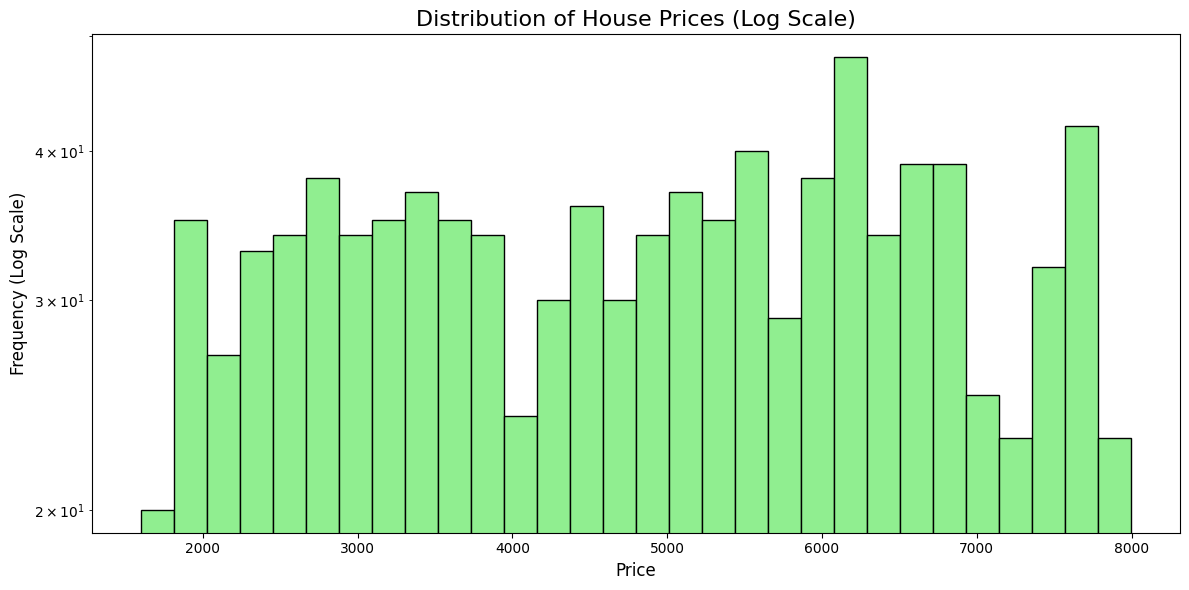

In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
#ABOUT THE DATASET
df=pd.read_csv("HousePricePrediction.csv")
df['Price']=(df['Price']/10000).astype(int)
print("\n\t\tTHE DATASET IS REGARDING THE HOUSE PRICE\n\n")
print(df,"\n\n")
print("\n\t\tTHE INFORMATION ABOUT THE COLUMNS OF DATASET\n\n")
df.info()
print("\n\n\n")
print(df.describe())
plt.figure(figsize=(12, 6))
plt.hist(df.iloc[:, -1], bins=30, color='lightgreen', edgecolor='black', log=True)
plt.title('Distribution of House Prices (Log Scale)', fontsize=16)
plt.xlabel('Price', fontsize=12)
plt.ylabel('Frequency (Log Scale)', fontsize=12)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# HANDLING MISSING VALUES

In [2]:
print(df.isnull().values.any())
print("COUNT OF NULL VALUE IS:  " + str(df.isnull().sum().sum()))
df.loc[df.loc[:,"House Age"].isna(),"House Age"]=math.floor(int(df["House Age"].mean()))
df.info()

True
COUNT OF NULL VALUE IS:  86
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Bedrooms         1000 non-null   int64  
 1   Bathrooms        1000 non-null   int64  
 2   Square Feet      1000 non-null   int64  
 3   House Age        1000 non-null   float64
 4   Location Rating  1000 non-null   int64  
 5   Price            1000 non-null   int64  
dtypes: float64(1), int64(5)
memory usage: 47.0 KB


# SPLITTING THE TRAINING AND TESTING DATA

X_train shape: (800, 5)
X_test shape: (200, 5)
y_train shape: (800,)
y_test shape: (200,)





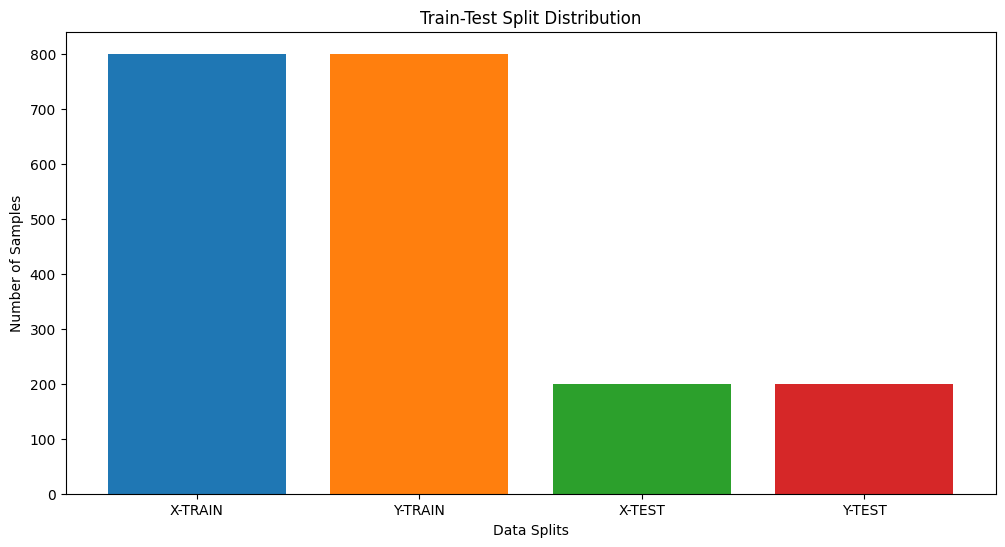

In [3]:
x = df.iloc[:, :-1].astype(float)
y = df.iloc[:, -1].astype(int)
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2,random_state=42)
print("X_train shape:", xtrain.shape)
print("X_test shape:", xtest.shape)
print("y_train shape:", ytrain.shape)
print("y_test shape:", ytest.shape)
print("\n\n")
x1=xtrain.shape[0]
x2=xtest.shape[0]
y1=ytrain.shape[0]
y2=ytest.shape[0]
plt.figure(figsize=(12,6))
plt.bar("X-TRAIN",x1)
plt.bar("Y-TRAIN",y1)
plt.bar("X-TEST",x2)
plt.bar("Y-TEST",y2)
plt.xlabel("Data Splits")
plt.ylabel("Number of Samples")
plt.title("Train-Test Split Distribution")
plt.show()

# KNN REGRESSION 

ENTER THE VALUE OF K 3


MAE: 9.414081952765681
MSE: 151.69243522663484
RMSE: 12.316348291057494


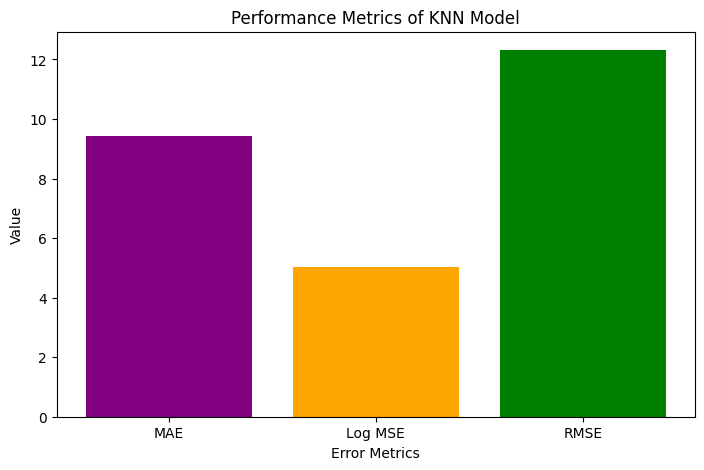

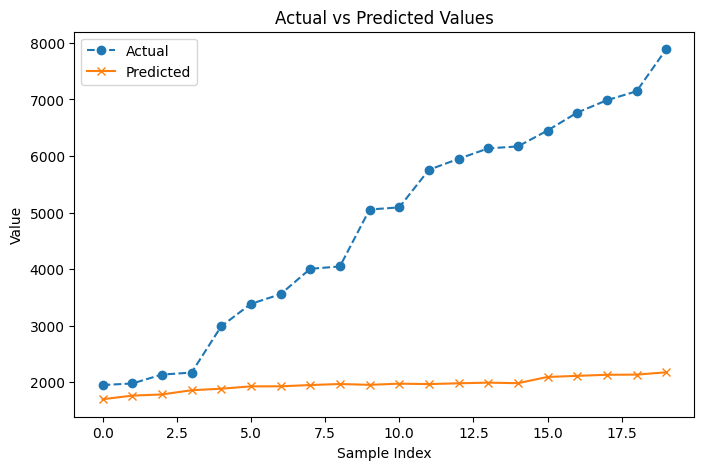

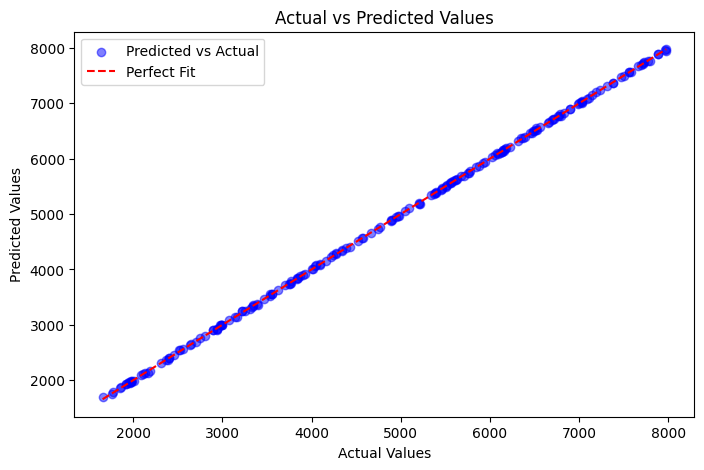

In [4]:
k = int(input("ENTER THE VALUE OF K"))

pred = np.zeros(xtest.shape[0])

for i in range(xtest.shape[0]):
    dist = np.sqrt(np.sum((xtrain.to_numpy() - xtest.iloc[i].to_numpy())**2, axis=1))
    kminind = np.argpartition(dist, k)[:k]
    invdist = 1 / (dist[kminind] + 1e-10)
    denom = np.sum(invdist)
    pred[i] = np.dot(invdist / denom, ytrain.iloc[kminind])

#Errors
mae = np.mean(abs(pred - ytest))
mse = np.mean((pred - ytest) ** 2)
rmse = np.sqrt(mse)
logmse = np.log1p(mse)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

#graph of errors
plt.figure(figsize=(8.23, 5))
plt.bar(["MAE", "Log MSE", "RMSE"], [mae, logmse, rmse], color=['purple', 'orange', 'green'])
plt.xlabel("Error Metrics")
plt.ylabel("Value")
plt.title("Performance Metrics of KNN Model")
plt.show()

#graph of predicted vs actual
ytestsorted = np.sort(ytest[:20])
predsorted = pred[np.argsort(ytest)][:20]

plt.figure(figsize=(8, 5))
plt.plot(ytestsorted, label='Actual', marker='o', linestyle='dashed')
plt.plot(predsorted, label='Predicted', marker='x', linestyle='solid')
plt.xlabel("Sample Index")
plt.ylabel("Value")
plt.title("Actual vs Predicted Values")
plt.legend()
plt.show()

# Scatter plot of predicted vs actual
plt.figure(figsize=(8, 5))
plt.scatter(ytest, pred, color='blue', alpha=0.5, label='Predicted vs Actual')
plt.plot([min(ytest), max(ytest)], [min(ytest), max(ytest)], color='red', linestyle='dashed', label='Perfect Fit')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.legend()
plt.show()


# Predictions

In [5]:
print("Predictions:", pred)

Predictions: [3368.1679532  6991.73236338 2129.00346594 4008.83929289 6767.33412334
 6172.03799856 6459.38472884 7143.32807047 7887.75392016 1947.65888165
 6126.55807583 3556.19494295 5104.53709091 2132.07368118 5746.23193882
 2990.63048837 5946.90965999 4076.4404468  1971.87264302 5057.48419725
 3919.3266711  3849.40731717 7768.80329256 5625.98509876 2458.34715824
 3515.54070312 7887.10260641 5351.39226093 3796.24843501 1965.93520424
 3352.67651274 2538.53690127 5749.19777907 7566.54548071 4895.78317593
 1781.43535852 6467.53219818 2764.23506907 6641.55152263 3741.17296518
 3712.9855735  3243.23574889 4568.37009566 4575.56290886 2110.32162122
 2999.         2567.29801482 7954.71768204 3251.28098774 5694.34514204
 5438.06389076 7010.8054912  2630.42076796 6364.70813151 5207.60863979
 7489.34252101 6190.75737615 1882.91789651 5694.48529103 6110.35406737
 6137.37799812 2372.32302236 2989.40431395 4953.20755599 7374.61090898
 5391.20192062 7103.40543536 7568.59952735 2999.         5616.60